# Tutorial 2: Large rasters

**What you'll do:**
- Execute {ref}`extended_install` and verify 
- Download and visualize a  test tile with large extents
- Run the Python API and compare a few options


## 1. Setup

The {ref}`extended_install` is more challenging as we leverage the powerful [GDAL library](https://gdal.org/en/stable/) for raster processing large rasters. 
Because GDAL is a performance-first, open-source, C++ library with Python layered on top and 100+ drivers that depends on a large stack of native libraries itself, new installs often break.

Therefore, the most reliable execution context for `floodsr` is local (i.e., not google colab), but we still give some experimental guidance for hosted environments.

Proceed based on your execution context:
- **command line (CLI)**: copy/paste the commands from {ref}`extended_install_cli` into your terminal
- **local notebook (Jupyter)**: same as above. then run the additional commands from {ref}`extended_install_notebook`. then re-launch this notebook or switch the kernel to that environment.
- **hosted notebook (Colab)**: see {ref}`extended_install_hosted_notebook` or un-comment the below and run.

In [ ]:
# colab experimental setup

 
# !apt-get update -qq
# !apt-get install -y -qq gdal-bin libgdal-dev
# !pip install -q --upgrade pip
# !pip install -q "gdal[numpy]==$(gdal-config --version).*" rasterio geopandas pyproj shapely fiona


# !pip install -q floodsr

## 1.1 Install Matplotlib

Uncomment the below if you do not have matplotlib installed

In [ ]:
#!pip install -q matplotlib

## 1.2 Environment Check

In [1]:
import importlib
import sys

packages = ["floodsr", "matplotlib", "rasterio"]
versions = {}
for name in packages:
    module = importlib.import_module(name)
    versions[name] = getattr(module, "__version__", "unknown")

print(f"python_executable={sys.executable}")
for name, version in versions.items():
    print(f"{name}_version={version}")


python_executable=/opt/conda/envs/dev/bin/python
floodsr_version=0.0.6.dev28
matplotlib_version=3.10.8
rasterio_version=1.5.0


## 1.3 Imports

In [ ]:
import importlib
import logging
import os
import sys
import tempfile
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import rasterio


## 1.4 Configure Logging

`floodsr`'s Python bindings use the standard Python logging system.
A simple `logging.basicConfig(...)` call is enough to surface progress and diagnostics while the notebook runs.

In [ ]:
logging.basicConfig(level=logging.INFO, force=True)
logger = logging.getLogger("tutorial_2")

INFO:tutorial_2:logging to /workspace/tutorial_2.log


## 2. Download Test Data

We use a clipped tile from the old [Aqueduct Floods Hazard Maps](https://wri-projects.s3.amazonaws.com/AqueductFloodTool/download/v2/index.html) dataset.
You can download this from our repo with the below:

In [ ]:
urlretrieve(
    "https://github.com/cefect/floodsr/releases/download/v0.0.9/inunriver_historical_000000000WATCH_1980_rp01000.tif",
    "inunriver_historical_000000000WATCH_1980_rp01000.tif",
)
lowres_fp = Path("inunriver_historical_000000000WATCH_1980_rp01000.tif").resolve()
assert lowres_fp.is_file(), f"could not find {lowres_fp}"

## 3. Visualize the Low-Res Input

In [ ]:
with rasterio.open(lowres_fp) as src:
    lowres = src.read(1).astype(float)
    if src.nodata is not None:
        lowres[lowres == src.nodata] = np.nan

plt.figure(figsize=(6, 4))
plt.imshow(np.where(lowres > 0, lowres, np.nan), cmap="Blues")
plt.title("Low-res input depth")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"LR depth shape: {lowres.shape}")

## 4. Fetch HRDEM

Here we use `floodsr`s builtin HRDEM fetcher.

This step can take a while on a first run because it may need to query the HRDEM catalog, download one or more source windows, and populate the local tile cache.



In [ ]:

hrdem_fp = Path(f"{lowres_fp.stem}_fetched_hrdem.vrt").resolve()


If you are fetching large HRDEM tiles repeatedly, setting `HRDEM_CACHE_DIR` to a persistent location is useful because it lets later runs reuse cached fetch tiles instead of downloading the same source windows again. If you do not set it, this notebook defaults to your Python temp directory.

In [6]:
hrdem_cache_dir = Path(os.getenv("HRDEM_CACHE_DIR", tempfile.gettempdir())).expanduser().resolve()

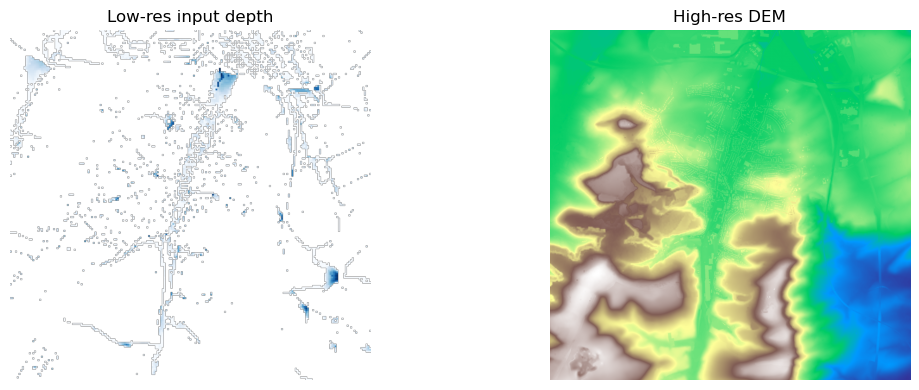

LR depth shape: (203, 209)
DEM shape:      (2030, 2090)


In [ ]:
from floodsr.dem_sources.hrdem_mosaic import main_fetch_hrdem_for_lowres_tile


hrdem_result = main_fetch_hrdem_for_lowres_tile(
    depth_lr_fp=lowres_fp,
    output_fp=hrdem_fp,
    cache_dir=hrdem_cache_dir,
    force_tiling=True,
    show_progress=True,
    logger=logger,
    use_cache=True,
)
hrdem_fp = Path(hrdem_result.dem_fp).expanduser().resolve()
print(f"HRDEM cache dir: {hrdem_cache_dir}")
print(f"HRDEM path:     {hrdem_fp}")

## 4.1 Visualize the Fetched HRDEM

In [5]:
with rasterio.open(hrdem_fp) as src:
    dem = src.read(1).astype(float)
    if src.nodata is not None:
        dem[dem == src.nodata] = float("nan")

plt.figure(figsize=(6, 4))
plt.imshow(dem, cmap="terrain")
plt.title("Fetched HRDEM")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"DEM shape:      {dem.shape}")

## 5. Fetch the Model

Download model weights once, then reuse the cached copy on later runs.

In [6]:
from floodsr.model_registry import fetch_model

model_version = "ResUNet_16x_DEM"
model_fp = fetch_model(model_version, show_progress=False)
print(model_fp)

INFO:floodsr.model_registry:attempting unauthenticated model download from
    https://github.com/cefect/floodsr/releases/download/v2026.02.19/model_infer.onnx


/root/.cache/floodsr/ResUNet_16x_DEM/model_infer.onnx


## 6. Run `tohr()`

The basic Python call takes a low-res depth raster with `depth_lr_fp` and a high-res DEM with `dem_hr_fp`.

This step can also take a while because it runs the full preprocessing and model inference pipeline on the fetched HRDEM raster.

In [7]:
from floodsr.tohr import tohr

result_fp = Path("result.tif").resolve()
result_meta = tohr(
    model_version=model_version,
    model_fp=model_fp,
    depth_lr_fp=lowres_fp,
    dem_hr_fp=hrdem_fp,
    output_fp=result_fp,
    show_progress=True,
    logger=logger,
)
print(result_meta["output_fp"])

INFO:floodsr.cli:loaded ORT model 'model_infer.onnx' with providers=['CPUExecutionProvider'] and scale=16


INFO:floodsr.cli:starting tohr inference with model_version=ResUNet_16x_DEM
model
    /root/.cache/floodsr/ResUNet_16x_DEM/model_infer.onnx
platform_depth_lr
    /tmp/floodsr-platform-prep-17rjqkq4/lowres030_platform_depth.tif
platform_dem_hr
    /tmp/floodsr-platform-prep-17rjqkq4/hires003_dem_platform_dem.tif
output
    /workspace/docs/user/notebooks/result.tif


INFO:floodsr.cli:platform-preprocessed inputs
  depth_lr shape=(203, 209) res=(30.0, 30.0) m/pix
  dem_hr shape=(2030, 2090) res=(3.0, 3.0) m/pix


INFO:floodsr.cli:model preprocessing complete
  scale=16 (HR/LR ratio)
  crs_policy=strict
  aligned depth shape=(203, 209) resampled=True
  aligned dem shape=(3248, 3344) raw_dem_shape=(2030, 2090)
  max_depth=5.0 dem_pct_clip=95.0
INFO:floodsr.cli:prepared inputs summary:
  aligned depth_lr shape=(203, 209) res=(30.0, 30.0) m/pix
  aligned dem_hr shape=(3248, 3344) res=(1.875, 1.875) m/pix
  max_depth=5.0
  dem_pct_clip=95.0
INFO:floodsr.cli:window config
  method=feather
  overlap_lr=8
  overlap_hr=128
  tile_size_lr=32
  tile_size_hr=512
INFO:floodsr.cli:running feather tiling over 9x9 grid
  stride_hr=384
  overlap_hr=128

feather pass:   0%|                                  | 0/81 [00:00<?, ?window/s]


feather pass:   2%|▋                         | 2/81 [00:00<00:04, 18.75window/s]

...


feather pass:  88%|█████████████████████▉   | 71/81 [00:01<00:00, 40.27window/s]


feather pass:  94%|███████████████████████▍ | 76/81 [00:02<00:00, 40.51window/s]


feather pass: 100%|█████████████████████████| 81/81 [00:02<00:00, 37.52window/s]


INFO:floodsr.cli:post-resampling model output from (3248, 3344) to (2030, 2090) on raw DEM grid with bilinear interpolation.


INFO:floodsr.cli:finished tohr inference in 2.847s; wrote 6,470,873 bytes to
    /workspace/docs/user/notebooks/result.tif
/workspace/docs/user/notebooks/result.tif


## 6.1 Visualize the Output

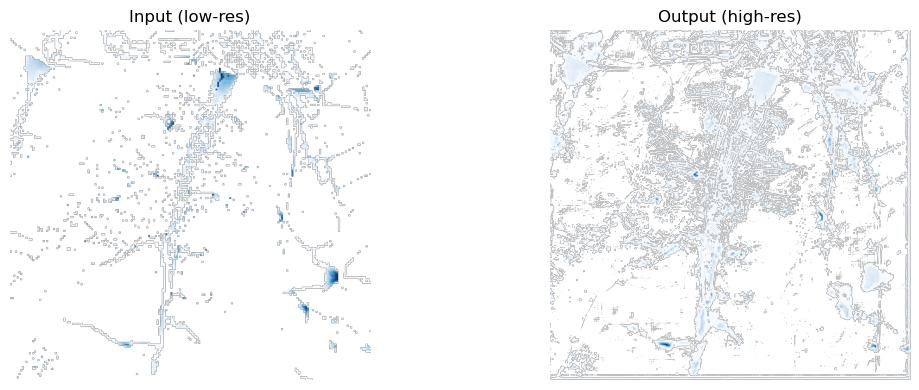

In [8]:
with rasterio.open("result.tif") as src:
    result = src.read(1).astype(float)
    if src.nodata is not None:
        result[result == src.nodata] = np.nan

plt.figure(figsize=(6, 4))
plt.imshow(np.where(result > 0, result, np.nan), cmap="Blues")
plt.title("Output depth")
plt.axis("off")
plt.tight_layout()
plt.show()